In [ ]:
# FAZA 6 — Modelovanje: nenadgledana detekcija anomalija (Isolation Forest, One-Class SVM)
#
# Za razliku od Faza 4 i 5, gde su modeli učili iz stvarnih labela, ovde se
# modeli treniraju bez target (is_attack) kolone. Pretpostavka je da su napadi retki
# izuzeci u odnosu na uobičajeno ponašanje, pa model uči kako izgleda normalan
# obrazac i svakom prozoru dodeljuje meru neobičnosti (anomaly score).
#
# Labela se koristi tek nakon treniranja, isključivo za evaluaciju da li se ono što
# je model označio kao izuzetak zaista poklapa sa stvarnim napadima.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

SEED = 7
np.random.seed(SEED)

In [ ]:
# --- 1. Učitavanje podataka iz Faze 3  ---
vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "features_full.json", encoding="utf-8") as f:
    atributi_full = json.load(f)
with open(PROC / "features_after_filter.json", encoding="utf-8") as f:
    atributi_filter = json.load(f)
with open(PROC / "selected_features.json", encoding="utf-8") as f:
    atributi_final = json.load(f)
with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)

# has_history se rekreira po istom pravilu kao u Fazi 4 (nije sačuvan u parquet-u).
vremenski_prozori["has_history"] = (vremenski_prozori["window_seq_num"] >= 1).astype(
    int
)

# Imputacija istim vrednostima izračunatim na treningu u Fazi 3.
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)

print("Ukupno redova:", len(vremenski_prozori))
print(f"Full: {len(atributi_full)} atributa")
print(f"Filter: {len(atributi_filter)} atributa")
print(f"Final: {len(atributi_final)} atributa")

Ukupno redova: 224180
Full: 53 atributa
Filter: 40 atributa
Final: 11 atributa


In [ ]:
# --- 2. Podela na train/val/test i skaliranje ---
# Skaliranje je neophodno za One-Class SVM, jer računa rastojanja u prostoru
# atributa. Bez njega bi atributi sa velikim opsegom dominirali granicom koju model uči. Isolation Forest seče prostor po atributu (nasumično bira atribut
# i tačku podele), pa mu skaliranje nije potrebno, on koristi isti skaliran skup samo iz praktičnih razloga. Skaler se, kao i u prethodnim fazama, uči samo na treningu.
train = vremenski_prozori[vremenski_prozori["split"] == "train"].reset_index(drop=True)
val = vremenski_prozori[vremenski_prozori["split"] == "valid"].reset_index(drop=True)
test = vremenski_prozori[vremenski_prozori["split"] == "test"].reset_index(drop=True)

y_train = train["is_attack"]
y_val = val["is_attack"]
y_test = test["is_attack"]

print(
    f"train: {len(train)} redova, {int(y_train.sum())} pozitivnih ({y_train.mean() * 100:.3f}%)"
)
print(
    f"val:   {len(val)} redova, {int(y_val.sum())} pozitivnih ({y_val.mean() * 100:.3f}%)"
)
print(
    f"test:  {len(test)} redova, {int(y_test.sum())} pozitivnih ({y_test.mean() * 100:.3f}%)"
)

skupovi_atributa = {
    f"Full ({len(atributi_full)})": atributi_full,
    f"Filter ({len(atributi_filter)})": atributi_filter,
    f"Final ({len(atributi_final)})": atributi_final,
}

datasets = {}
for naziv_skupa, kolone in skupovi_atributa.items():
    skaler = RobustScaler()
    X_tr = skaler.fit_transform(train[kolone])
    X_v = skaler.transform(val[kolone])
    datasets[naziv_skupa] = {
        "X_train": X_tr,
        "X_val": X_v,
        "skaler": skaler,
        "kolone": kolone,
    }

print("\nSkalirani skupovi spremni:", list(datasets.keys()))

train: 45685 redova, 101 pozitivnih (0.221%)
val:   17630 redova, 115 pozitivnih (0.652%)
test:  160865 redova, 35 pozitivnih (0.022%)

Skalirani skupovi spremni: ['Full (53)', 'Filter (40)', 'Final (11)']


In [ ]:
# --- 3. Funkcija za evaluaciju nenadgledanih modela ---
# Modeli vraćaju score_samples: što je vrednost niža, to je prozor neobičniji.
# Za evaluaciju se znak obrće, tj. veći broj znači "verovatnije anomalija",
# jer Average Precision očekuje da veći skor prati pozitivnu klasu.


def evaluate_unsupervised(model, X_tr, X_v, y_v):
    """Trenira model bez labele i vraća anomaly score i mere na validaciji."""
    model.fit(X_tr)
    skor_v = -model.score_samples(X_v)
    return skor_v, average_precision_score(y_v, skor_v), roc_auc_score(y_v, skor_v)

In [ ]:
# --- 4. Isolation Forest kroz tri skupa atributa i dve vrednosti kontaminacije ---
# contamination govori modelu koliki udeo podataka očekuje da bude anomalija.
# Porede se dve vrednosti: stvarni izmereni udeo napada u treningu (0.221%,
# Faza 2) i podrazumevana "auto" vrednost, da se vidi da li tačna informacija
# o učestalosti napada zaista pomaže.
STVARNI_UDEO = float(y_train.mean())
print(f"Stvarni udeo pozitivnih u treningu: {STVARNI_UDEO:.5f}")

rezultati_if = []
for naziv_skupa, d in datasets.items():
    for oznaka_kont, vrednost_kont in [("stvarni", STVARNI_UDEO), ("auto", "auto")]:
        model = IsolationForest(
            n_estimators=300,
            contamination=vrednost_kont,
            random_state=SEED,
            n_jobs=-1,
        )
        _, ap_v, auc_v = evaluate_unsupervised(model, d["X_train"], d["X_val"], y_val)
        rezultati_if.append(
            {
                "Skup": naziv_skupa,
                "Kontaminacija": oznaka_kont,
                "AP val": round(ap_v, 4),
                "AUC-ROC val": round(auc_v, 4),
            }
        )

if_rezultati = pd.DataFrame(rezultati_if)
print("\nIsolation Forest:")
print(if_rezultati.to_string(index=False))
# Najbolji je Filter skup (AP=0.0598, AUC=0.8914)
# Rezultati za contamination = "stvarni" i "auto" su identični kroz sva tri
# skupa. Score_samples() vraća anomaly score (prosečnu dužinu putanje kroz stabla),
# koji ne zavisi od contamination parametra. On utiče samo na offset_, tj. na prag
# koji predict() koristi za binarnu odluku.

Stvarni udeo pozitivnih u treningu: 0.00221

Isolation Forest:
       Skup Kontaminacija  AP val  AUC-ROC val
  Full (53)       stvarni  0.0443       0.8722
  Full (53)          auto  0.0443       0.8722
Filter (40)       stvarni  0.0598       0.8914
Filter (40)          auto  0.0598       0.8914
 Final (11)       stvarni  0.0580       0.9238
 Final (11)          auto  0.0580       0.9238


In [ ]:
# --- 5. One-Class SVM kroz tri skupa atributa ---
# One-Class SVM uči granicu koja obuhvata normalne tačke. Sve van te granice
# tretira kao anomaliju. Parametar nu ima ulogu sličnu kontaminaciji: gornja
# granica udela tačaka koje smeju pasti van granice.
# Model uči na hronološkom poduzorku, a zatim se primenjuje na celu validaciju.
OCSVM_SAMPLE_SIZE = 10_000

rezultati_ocsvm = []
for naziv_skupa, d in datasets.items():
    X_tr = d["X_train"]
    if len(X_tr) > OCSVM_SAMPLE_SIZE:
        korak = len(X_tr) // OCSVM_SAMPLE_SIZE
        X_tr_uzorak = X_tr[::korak]
    else:
        X_tr_uzorak = X_tr

    for oznaka_nu, vrednost_nu in [("stvarni", STVARNI_UDEO), ("podrazumevani", 0.5)]:
        model = OneClassSVM(kernel="rbf", nu=vrednost_nu, gamma="scale")
        _, ap_v, auc_v = evaluate_unsupervised(model, X_tr_uzorak, d["X_val"], y_val)
        rezultati_ocsvm.append(
            {
                "Skup": naziv_skupa,
                "nu": oznaka_nu,
                "AP val": round(ap_v, 4),
                "AUC-ROC val": round(auc_v, 4),
            }
        )

ocsvm_rezultati = pd.DataFrame(rezultati_ocsvm)
print(f"\nOne-Class SVM (trening na poduzorku od {OCSVM_SAMPLE_SIZE} redova):")
print(ocsvm_rezultati.to_string(index=False))

# Za razliku od Isolation Forest-a, kod One-Class SVM-a parametar nu
# drastično menja rezultat. Razlog je u mehanizmu jer "nu" oblikuje
# hiperravan tokom samog treniranja (nije naknadni prag kao contamination
# kod Isolation Forest-a), pa i score_samples() tj. rastojanje od hiperravni
# zavisi od njega.

# nu="stvarni" (0.00221) daje AUC-ROC ispod 0.5 na sva tri skupa (0.29-0.30).
# nu ograničava udeo tačaka koje smeju ostati van granice, pa ovako mala
# vrednost prisiljava granicu da obuhvati skoro sve (99.78%) trening tačke
# kao "normalne".
#
# Sa nu="podrazumevani" (0.5), AUC-ROC je solidan (0.83-0.85). Problem nije
# sam model, nego ekstremna osetljivost na malu vrednost nu.


One-Class SVM (trening na poduzorku od 10000 redova):
       Skup            nu  AP val  AUC-ROC val
  Full (53)       stvarni  0.0099       0.3042
  Full (53) podrazumevani  0.0257       0.8412
Filter (40)       stvarni  0.0100       0.2936
Filter (40) podrazumevani  0.0276       0.8493
 Final (11)       stvarni  0.0102       0.2974
 Final (11) podrazumevani  0.0282       0.8304


In [ ]:
# --- 6. Objedinjeni pregled i izbor najboljeg nenadgledanog modela ---
if_pregled = if_rezultati.copy()
if_pregled["Model"] = "Isolation Forest"
if_pregled["Parametar"] = if_pregled["Kontaminacija"]

ocsvm_pregled = ocsvm_rezultati.copy()
ocsvm_pregled["Model"] = "One-Class SVM"
ocsvm_pregled["Parametar"] = ocsvm_pregled["nu"]

kolone_pregleda = ["Model", "Skup", "Parametar", "AP val", "AUC-ROC val"]
svi_rezultati = pd.concat(
    [if_pregled[kolone_pregleda], ocsvm_pregled[kolone_pregleda]], ignore_index=True
)
svi_rezultati = svi_rezultati.sort_values("AP val", ascending=False)

print("Svi nenadgledani modeli, sortirano po AP na validaciji:")
print(svi_rezultati.to_string(index=False))

najbolji = svi_rezultati.iloc[0]
print(
    f"\nNajbolji nenadgledani: {najbolji['Model']} na skupu {najbolji['Skup']} "
    f"(parametar: {najbolji['Parametar']}), AP val = {najbolji['AP val']}"
)


print(f"\nAP slučajnog modela (bazna stopa validacije): {y_val.mean():.4f}")
print("Za poređenje - Faza 4 (Random Forest, nadgledano): AP val = 0.2332")
print("Za poređenje - Faza 5 (Transformer, nadgledano):   AP val = 0.0770")

svi_rezultati.to_csv(RESULTS / "faza6_poredjenje_nenadgledanih.csv", index=False)
print("\nSačuvano: results/faza6_poredjenje_nenadgledanih.csv")

Svi nenadgledani modeli, sortirano po AP na validaciji:
           Model        Skup     Parametar  AP val  AUC-ROC val
Isolation Forest Filter (40)          auto  0.0598       0.8914
Isolation Forest Filter (40)       stvarni  0.0598       0.8914
Isolation Forest  Final (11)          auto  0.0580       0.9238
Isolation Forest  Final (11)       stvarni  0.0580       0.9238
Isolation Forest   Full (53)       stvarni  0.0443       0.8722
Isolation Forest   Full (53)          auto  0.0443       0.8722
   One-Class SVM  Final (11) podrazumevani  0.0282       0.8304
   One-Class SVM Filter (40) podrazumevani  0.0276       0.8493
   One-Class SVM   Full (53) podrazumevani  0.0257       0.8412
   One-Class SVM  Final (11)       stvarni  0.0102       0.2974
   One-Class SVM Filter (40)       stvarni  0.0100       0.2936
   One-Class SVM   Full (53)       stvarni  0.0099       0.3042

Najbolji nenadgledani: Isolation Forest na skupu Filter (40) (parametar: auto), AP val = 0.0598

AP slučajnog m

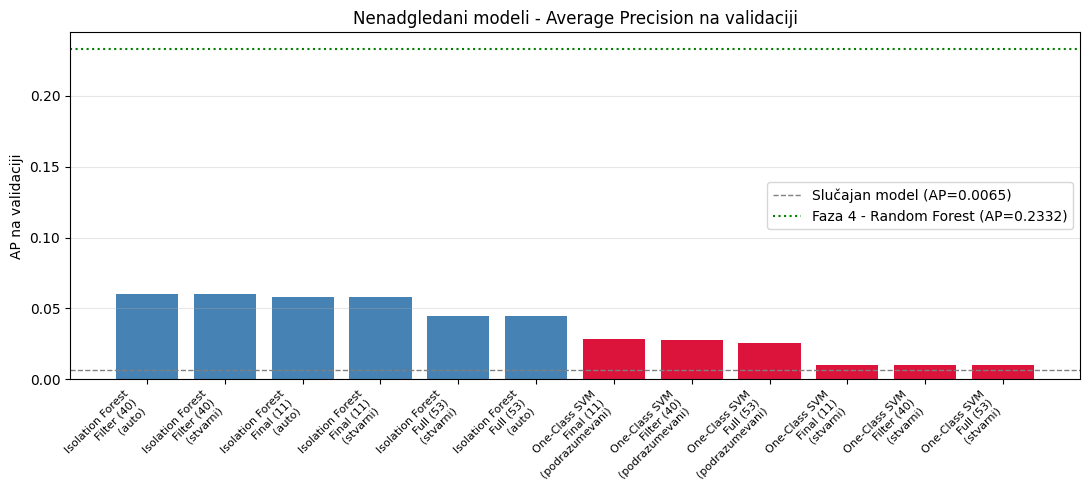

Grafik sačuvan: results/faza6_poredjenje_nenadgledanih.png


In [ ]:
# --- 7. Vizuelno poređenje nenadgledanih modela ---
fig, ax = plt.subplots(figsize=(11, 5))
oznake = (
    svi_rezultati["Model"]
    + "\n"
    + svi_rezultati["Skup"]
    + "\n("
    + svi_rezultati["Parametar"]
    + ")"
)
boje = [
    "steelblue" if m == "Isolation Forest" else "crimson"
    for m in svi_rezultati["Model"]
]

ax.bar(range(len(svi_rezultati)), svi_rezultati["AP val"], color=boje)
ax.axhline(
    y_val.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model (AP={y_val.mean():.4f})",
)
ax.axhline(
    0.2332,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label="Faza 4 - Random Forest (AP=0.2332)",
)
ax.set_xticks(range(len(svi_rezultati)))
ax.set_xticklabels(oznake, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("AP na validaciji")
ax.set_title("Nenadgledani modeli - Average Precision na validaciji")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS / "faza6_poredjenje_nenadgledanih.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza6_poredjenje_nenadgledanih.png")

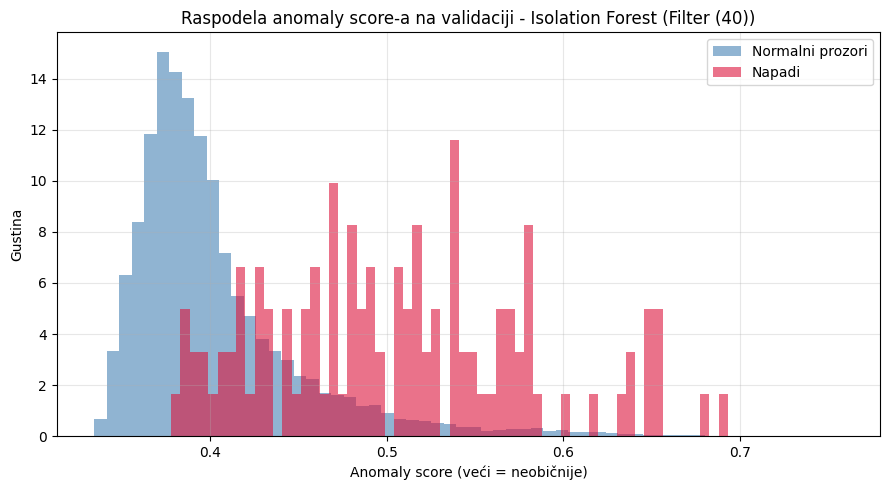

Grafik sačuvan: results/faza6_raspodela_skora.png

Prosečan skor - normalni prozori: 0.4028
Prosečan skor - napadi:           0.5052


In [ ]:
# --- 8. Anomaly score najboljeg modela: napadi naspram normalnih prozora ---
# Provera osnovne pretpostavke cele faze: da li prozori koje je model označio
# kao izuzetke zaista odgovaraju napadima. Ako se raspodele skora za dve klase
# jasno razdvajaju, pretpostavka drži; ako se preklapaju, ne drži.
naziv_najboljeg = najbolji["Model"]
skup_najboljeg = najbolji["Skup"]
d_najbolji = datasets[skup_najboljeg]

if naziv_najboljeg == "Isolation Forest":
    kont = STVARNI_UDEO if najbolji["Parametar"] == "stvarni" else "auto"
    model_najbolji = IsolationForest(
        n_estimators=300, contamination=kont, random_state=SEED, n_jobs=-1
    )
    X_tr_najbolji = d_najbolji["X_train"]
else:
    nu_vrednost = STVARNI_UDEO if najbolji["Parametar"] == "stvarni" else 0.5
    model_najbolji = OneClassSVM(kernel="rbf", nu=nu_vrednost, gamma="scale")
    korak = len(d_najbolji["X_train"]) // OCSVM_SAMPLE_SIZE
    X_tr_najbolji = (
        d_najbolji["X_train"][::korak] if korak > 1 else d_najbolji["X_train"]
    )

skor_val, ap_val_najbolji, auc_val_najbolji = evaluate_unsupervised(
    model_najbolji, X_tr_najbolji, d_najbolji["X_val"], y_val
)

plt.figure(figsize=(9, 5))
plt.hist(
    skor_val[y_val == 0],
    bins=60,
    alpha=0.6,
    label="Normalni prozori",
    color="steelblue",
    density=True,
)
plt.hist(
    skor_val[y_val == 1],
    bins=60,
    alpha=0.6,
    label="Napadi",
    color="crimson",
    density=True,
)
plt.xlabel("Anomaly score (veći = neobičnije)")
plt.ylabel("Gustina")
plt.title(
    f"Raspodela anomaly score-a na validaciji - {naziv_najboljeg} ({skup_najboljeg})"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza6_raspodela_skora.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza6_raspodela_skora.png")

print(f"\nProsečan skor - normalni prozori: {skor_val[y_val == 0].mean():.4f}")
print(f"Prosečan skor - napadi:           {skor_val[y_val == 1].mean():.4f}")

# Normalni prozori imaju uzak, jednomodalan vrh oko 0.37-0.38, sa tankim
# repom koji se proteže do otprilike 0.65-0.67. Napadi počinju oko 0.38
# i nastavljaju se do skoro 0.70 bez izraženog vrha.
#
# Ispod 0.38 preklapanja nema (čisto normalni prozori), ali od 0.38 pa
# nadalje se dve klase preklapaju kroz veći deo preostalog opsega. Kod
# balansiranih klasa ovo preklapanje bi umereno oštetilo preciznost.
# Ovde dodatno utiče disbalans, čak i mali procenat od
# 17515 normalnih prozora koji upadne u tu zonu je veći od svih 115 napada,
# pa preciznost naglo pada iako je AUC-ROC i dalje dobar.

Najbolji nenadgledani model: Isolation Forest (Filter (40))
Izabrani prag: 0.537602
Na validaciji -> preciznost: 0.0792, odziv: 0.3478, F1: 0.1290
Uhvaćeno napada: 40 od 115, promašeno: 75
Lažnih uzbuna: 465 ukupno, 116.2 po danu


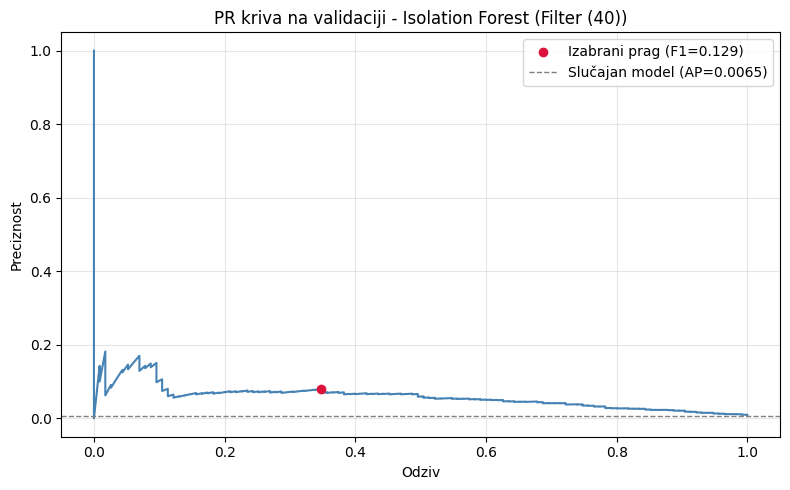

Grafik sačuvan: results/faza6_pr_kriva_validacije.png


In [ ]:
# --- 9. Biranje praga odlučivanja na validaciji ---
# Isti postupak kao u Fazama 4 i 5: prag koji maksimizuje F1-meru na
# validaciji, pa se taj isti prag kasnije primenjuje na test skup.
preciznost, odziv, pragovi = precision_recall_curve(y_val, skor_val)
f1 = 2 * preciznost * odziv / (preciznost + odziv + 1e-12)
najbolji_idx = int(np.argmax(f1[:-1]))
prag = float(pragovi[najbolji_idx])

print(f"Najbolji nenadgledani model: {naziv_najboljeg} ({skup_najboljeg})")
print(f"Izabrani prag: {prag:.6f}")
print(
    f"Na validaciji -> preciznost: {preciznost[najbolji_idx]:.4f}, "
    f"odziv: {odziv[najbolji_idx]:.4f}, F1: {f1[najbolji_idx]:.4f}"
)

y_pred_val = (skor_val >= prag).astype(int)
tp = int(((y_pred_val == 1) & (y_val == 1)).sum())
fp = int(((y_pred_val == 1) & (y_val == 0)).sum())
fn = int(((y_pred_val == 0) & (y_val == 1)).sum())
dana_u_validaciji = val["day"].nunique()
print(f"Uhvaćeno napada: {tp} od {int(y_val.sum())}, promašeno: {fn}")
print(f"Lažnih uzbuna: {fp} ukupno, {fp / dana_u_validaciji:.1f} po danu")

plt.figure(figsize=(8, 5))
plt.plot(odziv, preciznost, color="steelblue")
plt.scatter(
    odziv[najbolji_idx],
    preciznost[najbolji_idx],
    color="crimson",
    zorder=5,
    label=f"Izabrani prag (F1={f1[najbolji_idx]:.3f})",
)
plt.axhline(
    y_val.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model (AP={y_val.mean():.4f})",
)
plt.xlabel("Odziv")
plt.ylabel("Preciznost")
plt.title(f"PR kriva na validaciji - {naziv_najboljeg} ({skup_najboljeg})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza6_pr_kriva_validacije.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza6_pr_kriva_validacije.png")

# Na izabranom pragu: preciznost 7.9%, odziv 34.78%, F1=0.1290, oko 116
# lažnih uzbuna dnevno. U stvarnom SOC okruženju analitičar bi morao da
# pregleda preko 100 alarma dnevno da bi uhvatio manje od polovine pravih napada,
# što model na ovom pragu čini teško upotrebljivim.
#
# Ovde takođe uočavamo istu stvar o kojoj je bilo reči u Fazama 4 i 5: AUC-ROC od
# 0.89 deluje solidno, a Average Precision i stvarna preciznost pokazuju
# sasvim drugu sliku. Ta razlika povezuje sve tri faze modelovanja.

In [ ]:
# --- 10. Čuvanje najboljeg modela i konfiguracije ---
# Model se čuva radi finalne test evaluacije, bez ponovnog treniranja
# i bez diranja test skupa pre tog trenutka.
joblib.dump(model_najbolji, MODELS / "faza6_najbolji_model.pkl")
joblib.dump(d_najbolji["skaler"], MODELS / "faza6_skaler.pkl")

konfiguracija = {
    "model": naziv_najboljeg,
    "skup_atributa": skup_najboljeg,
    "parametar": str(najbolji["Parametar"]),
    "kolone": d_najbolji["kolone"],
    "prag": prag,
    "ap_validacija": float(ap_val_najbolji),
    "auc_validacija": float(auc_val_najbolji),
}
with open(MODELS / "faza6_konfiguracija.json", "w", encoding="utf-8") as f:
    json.dump(konfiguracija, f, ensure_ascii=False, indent=2)

print("Sačuvano: models/faza6_najbolji_model.pkl")
print("Sačuvano: models/faza6_skaler.pkl")
print("Sačuvano: models/faza6_konfiguracija.json")

Sačuvano: models/faza6_najbolji_model.pkl
Sačuvano: models/faza6_skaler.pkl
Sačuvano: models/faza6_konfiguracija.json
